In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
len(words)

32033

In [13]:
t = {}
for w in words:
    chs = '.' + w + '.'
    for i in range(len(chs)-2):
        trigram = (chs[i:i+2],chs[i+2])
        t[trigram] = t.get(trigram, 0) + 1
t

{('.e', 'm'): 288,
 ('em', 'm'): 100,
 ('mm', 'a'): 72,
 ('ma', '.'): 174,
 ('.o', 'l'): 104,
 ('ol', 'i'): 69,
 ('li', 'v'): 54,
 ('iv', 'i'): 78,
 ('vi', 'a'): 147,
 ('ia', '.'): 903,
 ('.a', 'v'): 243,
 ('av', 'a'): 161,
 ('va', '.'): 93,
 ('.i', 's'): 124,
 ('is', 'a'): 142,
 ('sa', 'b'): 76,
 ('ab', 'e'): 173,
 ('be', 'l'): 201,
 ('el', 'l'): 822,
 ('ll', 'a'): 337,
 ('la', '.'): 684,
 ('.s', 'o'): 152,
 ('so', 'p'): 21,
 ('op', 'h'): 37,
 ('ph', 'i'): 61,
 ('hi', 'a'): 81,
 ('.c', 'h'): 352,
 ('ch', 'a'): 236,
 ('ha', 'r'): 329,
 ('ar', 'l'): 287,
 ('rl', 'o'): 44,
 ('lo', 't'): 14,
 ('ot', 't'): 34,
 ('tt', 'e'): 121,
 ('te', '.'): 175,
 ('.m', 'i'): 393,
 ('mi', 'a'): 95,
 ('.a', 'm'): 384,
 ('am', 'e'): 226,
 ('me', 'l'): 188,
 ('el', 'i'): 537,
 ('li', 'a'): 518,
 ('.h', 'a'): 505,
 ('ar', 'p'): 8,
 ('rp', 'e'): 5,
 ('pe', 'r'): 77,
 ('er', '.'): 683,
 ('.e', 'v'): 154,
 ('ev', 'e'): 142,
 ('ve', 'l'): 76,
 ('el', 'y'): 353,
 ('ly', 'n'): 976,
 ('yn', '.'): 953,
 ('.a', 'b'):

In [14]:
sorted(t.items(), key = lambda kv: -kv[1])

[(('ah', '.'), 1714),
 (('na', '.'), 1673),
 (('an', '.'), 1509),
 (('on', '.'), 1503),
 (('.m', 'a'), 1453),
 (('.j', 'a'), 1255),
 (('.k', 'a'), 1254),
 (('en', '.'), 1217),
 (('ly', 'n'), 976),
 (('yn', '.'), 953),
 (('ar', 'i'), 950),
 (('ia', '.'), 903),
 (('ie', '.'), 858),
 (('an', 'n'), 825),
 (('el', 'l'), 822),
 (('an', 'a'), 804),
 (('ia', 'n'), 790),
 (('ma', 'r'), 776),
 (('in', '.'), 766),
 (('el', '.'), 727),
 (('ya', '.'), 716),
 (('an', 'i'), 703),
 (('.d', 'a'), 700),
 (('la', '.'), 684),
 (('er', '.'), 683),
 (('iy', 'a'), 669),
 (('la', 'n'), 647),
 (('.b', 'r'), 646),
 (('nn', 'a'), 633),
 (('.a', 'l'), 632),
 (('.c', 'a'), 628),
 (('ra', '.'), 627),
 (('ni', '.'), 625),
 (('.a', 'n'), 623),
 (('nn', '.'), 619),
 (('ne', '.'), 607),
 (('ee', '.'), 605),
 (('ey', '.'), 602),
 (('.k', 'e'), 601),
 (('al', 'e'), 601),
 (('.s', 'a'), 595),
 (('al', 'i'), 575),
 (('sh', 'a'), 562),
 (('el', 'i'), 537),
 (('.d', 'e'), 524),
 (('li', 'a'), 518),
 (('le', 'e'), 517),
 (('y

In [16]:
chars = sorted(list(set(''.join(words))))
ctoi = {s:i+1 for i,s in enumerate(chars)}
ctoi['.'] = 0
def stoi(text):
    tr = 0;
    for index, char in enumerate(text[::-1]):
        tr += (27**index)*ctoi[char]
    return tr

In [17]:
stoi('.a')

1

In [18]:
stoi('zz')

728

In [19]:
import torch

In [38]:
N = torch.zeros((729, 27), dtype=torch.int32)

for w in words:
    chs = '..' + w + '.'
    for i in range(len(chs)-2):
        # print('chars are', chs[i:i+2], ' ', chs[i+2] )
        # print('values are', stoi(chs[i:i+2]), ' ', ctoi[chs[i+2]])
        N[stoi(chs[i:i+2]), ctoi[chs[i+2]] ] += 1

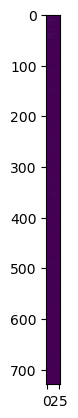

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [41]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [42]:
stoi('ah')

35

In [43]:
N[35]

tensor([1714,  111,    3,    2,   11,   46,    1,    0,    1,  101,    7,   15,
          73,   88,   57,    9,    1,    1,   34,   17,    1,    8,    5,    1,
           0,   11,   14], dtype=torch.int32)

In [44]:
P = N.float()
P = P/P.sum(1, keepdim = True)

In [46]:
P[35].sum()

tensor(1.0000)

In [50]:
g = torch.Generator().manual_seed(2147483647)
itoc = {i:c for c,i in ctoi.items()}
out = []
ix = 0
while True:
    last_char_from_ix = itoc[ix%27]
    p = P[ix]
    new_char_int = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    new_char = itoc[new_char_int]
    out.append(new_char)
    if new_char_int == 0:
        break
    ix = stoi(last_char_from_ix + new_char)
out

['c', 'e', '.']

In [51]:
# lets do this a bunch of times and hope for better results
P = N.float()
P /= P.sum(1, keepdim = True)

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        last_char_from_ix = itoc[ix%27]
        p = P[ix]
        new_char_int = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        new_char = itoc[new_char_int]
        out.append(new_char)
        if new_char_int == 0:
            break
        ix = stoi(last_char_from_ix + new_char)
    print(''.join(out))

ce.
bra.
jalius.
rochityharlonimittain.
luwak.


In [52]:
for w in words[:3]:
    chs = '..' + w + '.'
    for i in range(len(chs)-2):
        start = chs[i:i+2]
        end = chs[i+2]
        prob = P[stoi(start), ctoi[end] ]
        print(f'{start}{end}: {prob: .4f}')

..e:  0.0478
.em:  0.1881
emm:  0.1300
mma:  0.4286
ma.:  0.0672
..o:  0.0123
.ol:  0.2640
oli:  0.1115
liv:  0.0218
ivi:  0.2900
via:  0.1614
ia.:  0.3693
..a:  0.1377
.av:  0.0551
ava:  0.1930
va.:  0.1449


In [54]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = '..' + w + '.'
    for i in range(len(chs)-2):
        start = chs[i:i+2]
        end = chs[i+2]
        prob = P[stoi(start), ctoi[end] ]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n+=1
        # print(f'{start}{end}: {prob: .4f} {logprob: .4f} {log_likelihood: .4f}')

print(f'{log_likelihood=}')
nll = - log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-498647.7812)
nll=tensor(498647.7812)
2.185652017593384


In [56]:
log_likelihood = 0.0
n = 0

for w in ['ribhuuuuu']:
    chs = '..' + w + '.'
    for i in range(len(chs)-2):
        start = chs[i:i+2]
        end = chs[i+2]
        prob = P[stoi(start), ctoi[end] ]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n+=1
        # print(f'{start}{end}: {prob: .4f} {logprob: .4f} {log_likelihood: .4f}')

print(f'{log_likelihood=}')
nll = - log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-inf)
nll=tensor(inf)
inf


In [88]:
import torch.nn.functional as F
# generate dataset
xs, ys = [], []
for w in words:
    chs = '..' + w + '.'
    for i in range(len(chs)-2):
        start = chs[i:i+2]
        end = chs[i+2]
        xs.append(stoi(start))
        ys.append(ctoi[end])
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('num of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((729, 27), generator=g, requires_grad=True)

num of examples:  228146


In [92]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=729).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  # counts = logits.exp() # counts, equivalent to N
  # probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  # loss = -probs[torch.arange(num), ys].log().mean() + 0.05*(W**2).mean()
  loss = F.cross_entropy(logits, ys)  
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -100 * W.grad

2.3812062740325928
2.3797285556793213
2.3782742023468018
2.376842737197876
2.3754336833953857
2.3740460872650146
2.3726799488067627
2.3713343143463135
2.370008945465088
2.3687033653259277
2.3674168586730957
2.366149425506592
2.3649001121520996
2.36366868019104
2.362455129623413
2.3612585067749023
2.3600785732269287
2.358915090560913
2.3577675819396973
2.3566362857818604
2.3555197715759277
2.3544185161590576
2.3533318042755127
2.352259874343872
2.3512020111083984
2.3501579761505127
2.3491270542144775
2.3481099605560303
2.3471055030822754
2.346114158630371
2.345134973526001
2.3441686630249023
2.3432137966156006
2.342271327972412
2.3413400650024414
2.3404202461242676
2.3395113945007324
2.338613986968994
2.3377270698547363
2.336850643157959
2.335984945297241
2.3351292610168457
2.3342835903167725
2.3334474563598633
2.3326210975646973
2.3318045139312744
2.3309972286224365
2.3301992416381836
2.3294098377227783
2.328629732131958
2.3278582096099854
2.3270952701568604
2.326340913772583
2.3255944

In [95]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    last_char_from_ix = itoc[ix%27]
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    # xenc = F.one_hot(torch.tensor([ix]), num_classes=729).float()
    logits = W[ix] # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum() # probabilities for next character
    # ----------
    
    new_char_int = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    new_char = itoc[new_char_int]
    out.append(new_char)
    if new_char_int == 0:
      break
    ix = stoi(last_char_from_ix + new_char)
  print(''.join(out))

cexzdfzjglkuriana.
kayhhmvlzimilea.
noluwan.
ka.
da.


In [94]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  # Start with the context of two dots (index 0 in a 729-sized mapping if '.' is 0)
  # Or track it explicitly as a string:
  context = ".." 
  
  while True:
    ix = stoi(context) # Convert the 2-character string directly to its 0-728 index
    
    xenc = F.one_hot(torch.tensor([ix]), num_classes=729).float()
    logits = xenc @ W 
    counts = logits.exp() 
    p = counts / counts.sum(1, keepdims=True) 
    
    new_char_int = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    new_char = itoc[new_char_int]
    out.append(new_char)
    
    if new_char_int == 0:
      break
      
    # Shift the window: drop the oldest char, keep the second, append the new one
    context = context[1] + new_char 
    
  print(''.join(out))

cexzdfzjglkuriana.
kayhhmvlzimilea.
noluwan.
ka.
da.


1. This is a bit better than bi-gram, but the names are not great.